# **TP5 - Clustering**

<b>Exploratory Data Analysis & Unsuperivsed Learning </b><br>
**Lecturer: Dr. HAS Sothea** <br>
**TP: Mr. UANN Sreyvi**

-------

**Objective**: Clustering is technique of ML and Data Analysis used to group similar data points together. The goal is to partition a dataset into distinct subsets, or clusters, such that data points within each cluster are more similar to each other than to those in other clusters. This practical class aims to enhance your understanding of two different clustering algorithms, including their strengths and weaknesses.

---------

> **The `Jupyter Notebook` for this TP can be downloaded here: [TP5-Clustering](https://hassothea.github.io/EDA_ITC/TPs/TP5_Clustering.ipynb)**.

-------

## 1. Kmeans Algorithm

We will begin with a toy example using simulated dataset.

**a.** Implement a function, `simulateData(K, N)`, that generates a synthetic dataset for K-Means clustering. The dataset must consist of `K` distinct clusters, each containing `N` observations drawn from a 2D or 3D multivariate normal distribution. Select a value for `K` where $K\in\{3,…,8\}$ and visualize the output to verify that the cluster centers are sufficiently separated.

In [2]:
import numpy as np
import pandas as pd

def simulateData(K, N, dim=2, cluster_std=1.5, random_state=82):
    """
    Generate synthetic data for K-Means Clustering using multivariate normal distributions.

    Paramters:
    - K: int, the number of clusters (3 <= K <= 8)
    - N: int, the number of observations per cluster 
    - dim: int, the dimensionality of features (2D or 3D)
    - cluster_std: float, standard deviation of clusters
    - random_state: int, for consistency

    Returns:
    - data: pandas DataFrame with features
    - labels:  np array of cluster labels
    """

    assert 3 <= K <= 8
    assert dim in [2, 3]

    np.random.seed(random_state)
    # randomly get the center points
    centers = np.random.uniform(-10, 10, size=(K, dim))

    data_list = []
    labels_list = []

    for i, center in enumerate(centers):
        # diagonal matrix * sigma**2
        cov_matrix = np.eye(dim) * cluster_std**2
        # random points from multivariate normal
        points = np.random.multivariate_normal(mean=center, cov=cov_matrix, size=N)
        data_list.append(points)
        labels_list.append([i]*N)

    df = pd.DataFrame(np.vstack(data_list), columns=[f'x{j+1}' for j in range(dim)])
    labels = np.array(labels_list)

    return df, labels

In [3]:
K = 4
N = 100
df, labels = simulateData(K, N)
df.head()

,x1,x2
0,-5.067816,2.321442
1,-2.413853,5.359364
2,-2.913920,1.939606
3,-3.826238,5.783682
4,-4.136978,4.298698


In [4]:
import plotly.express as px

new_label = [str(i) for lab in labels for i in lab]
df['cluster'] = new_label

fig = px.scatter(df, x='x1', y='x2', color='cluster', width=800, height=600, title=f'Synthetic Data')
fig.show()

**b.** We are trying to detect the number of clsuter $k$ using **Within-class variance**:

- Check the equality: `Within-class variation` + `Between-class variation` = `Total variation`.
- Perform `Kmeans` algorithm using `KMeans` from `sklearn.cluster` module with different numbers of clusters and compute within-class variation or each case. 
- Draw the values of within-class variances as a function of number of cluster.
- What do you observe?

In [5]:
df['cluster'].unique()

array(['0', '1', '2', '3'], dtype=object)

In [6]:
mu = df[['x1', 'x2']].mean().values

SST = np.sum((df[['x1', 'x2']].values - mu) ** 2)


SSW = 0
for k, group in df.groupby('cluster'):
    cluster_mean = group[['x1', 'x2']].mean().values
    SSW += np.sum((group[['x1', 'x2']].values - cluster_mean)**2)

SSB = 0
for k, group in df.groupby('cluster'):
    n_k = len(group)
    cluster_mean = group[['x1', 'x2']].mean().values
    SSB += n_k * np.sum((cluster_mean - mu)**2)

print(f"Check: SST ≈ SSW + SSB -> {SST:.4f} ≈ {SSW:.4f} + {SSB:.4f} ≈ {SSW + SSB:.4f}")

Check: SST ≈ SSW + SSB -> 14545.7392 ≈ 1803.9315 + 12741.8076 ≈ 14545.7392


In [7]:
from sklearn.cluster import KMeans
X = df[['x1', 'x2']]

ssw_list = [] 

for n in range(1, 10):
    kmean = KMeans(n_clusters=n, random_state=82).fit(X)
    ssw_list.append({'k': n, 'ssw': kmean.inertia_})
ssw_list

[{'k': 1, 'ssw': 14545.739168442004},
 {'k': 2, 'ssw': 5765.456450179172},
 {'k': 3, 'ssw': 2631.7814414361706},
 {'k': 4, 'ssw': 1639.133548705492},
 {'k': 5, 'ssw': 1439.7354432859577},
 {'k': 6, 'ssw': 1266.157798918963},
 {'k': 7, 'ssw': 1112.0924469858867},
 {'k': 8, 'ssw': 1025.595770470943},
 {'k': 9, 'ssw': 924.5369845062376}]

In [8]:
ssw_df = pd.DataFrame(ssw_list)
fig = px.line(ssw_df, x='k', y='ssw', width=700, height=500, markers=True, title='Elbow Method for Optimal k')
fig.update_traces(line=dict(width=2))
fig.update_layout(xaxis_title='Number of clusters (k)',
                  yaxis_title='Within-cluster variation (SSW)')
fig.show()

> High drop in SSW for k in [1, 3] but add k = 4, SSW drop slightly 

**c.** Can you propose a systematic approach to approximate the most suitable number of clusters?

- Run your code $30$ times on the same data, how many times did you get the number of clusters right? Why?
- Try to set argument `n_init = 5` in `KMeans` module then use the previous method to approximate the optimal number of clusters. This time, within $30$ runs, how many times do you get the number of clusters right? Explain why.

In [46]:
def find_best_k(ssw_df):
    x = ssw_df['k'].values
    y = ssw_df['ssw'].values

    x1, y1 = x[0], y[0]
    x2, y2 = x[-1], y[-1]

    distances = np.abs((y2 - y1)*x - (x2 - x1)*y + x2*y1 - y2*x1) / np.sqrt((y2 - y1)**2 + (x2 - x1)**2)

    best_k = x[np.argmax(distances)]
    return best_k, distances

best_k, distances = find_best_k(ssw_df)
print(best_k)

3


In [47]:
for i in range(30):
    ssw_list = [] 
    for n in range(1, 10):
        kmean = KMeans(n_clusters=n).fit(X)
        ssw_list.append({'k': n, 'ssw': kmean.inertia_})

    ssw_df = pd.DataFrame(ssw_list)
    best_k, distances = find_best_k(ssw_df)
    print(f'i = {i}, best K = {best_k} with distance = {np.max(distances)}')

i = 0, best K = 3 with distance = 4.961881514357098
i = 1, best K = 3 with distance = 4.98139788340557
i = 2, best K = 3 with distance = 4.978901896280978
i = 3, best K = 3 with distance = 4.9625888923044785
i = 4, best K = 3 with distance = 4.974412083512798
i = 5, best K = 3 with distance = 4.96778279342039
i = 6, best K = 3 with distance = 5.0166491585256665
i = 7, best K = 3 with distance = 4.961102804724066
i = 8, best K = 3 with distance = 5.008707945443008
i = 9, best K = 3 with distance = 5.001645349507991
i = 10, best K = 3 with distance = 4.981152131191435
i = 11, best K = 3 with distance = 5.007217012579092
i = 12, best K = 3 with distance = 5.007656174119682
i = 13, best K = 3 with distance = 4.961537558725822
i = 14, best K = 3 with distance = 4.979556847614748
i = 15, best K = 3 with distance = 4.99692140242448
i = 16, best K = 3 with distance = 4.980768335427954
i = 17, best K = 3 with distance = 5.009479171295051
i = 18, best K = 3 with distance = 4.963866826851324
i = 

In [50]:
ssw_list = [] 
for n in range(1, 10):
    kmean = KMeans(n_init=30, n_clusters=n).fit(X)
    ssw_list.append({'k': n, 'ssw': kmean.inertia_})

ssw_df = pd.DataFrame(ssw_list)
best_k, distances = find_best_k(ssw_df)

print(f'best K = {best_k} with distance = {np.max(distances):.4f}')

best K = 3 with distance = 4.9623


**d.** Compute and visualize Silhouette Coefficient for each number of clusters considered above. Conclude.

In [64]:
from sklearn.metrics import silhouette_score

kmean = KMeans(n_init=30, n_clusters=3).fit(X)
labels = kmean.labels_

ss = silhouette_score(X=X, labels=labels)
print(ss)

0.5657981555867991


In [66]:
from sklearn.metrics import silhouette_samples
import plotly.graph_objects as go

sil_vals = silhouette_samples(X, labels)
y_lower = 0
fig = go.Figure()

for i in range(k):
    # silhouette values for cluster i
    cluster_sil_vals = sil_vals[labels == i]
    cluster_sil_vals.sort()  # sort for visualization
    cluster_size = cluster_sil_vals.shape[0]
    y_upper = y_lower + cluster_size

    fig.add_trace(go.Bar(
        x=cluster_sil_vals,
        y=np.arange(y_lower, y_upper),
        orientation='h',
        name=f'Cluster {i}',
        marker=dict(line=dict(width=0))
    ))

    y_lower = y_upper + 10  # add gap between clusters

    # Layout
fig.update_layout(
    title=f"Silhouette Plot for K=3",
    xaxis_title="Silhouette Coefficient",
    yaxis_title="Sample Index",
    barmode='stack',
    width=900,
    height=600,
    showlegend=True
)

fig.show()

## 2. [Hirachical clustering](https://en.wikipedia.org/wiki/Hierarchical_clustering)

Unlike `Kmeans` algrithm, `Hirachical clustering` or `hcluster` does not require a prior number of clusters. It iteratively merges (agglomerative or bottom up approach) into less and less clusters starting from each points being a cluster on its own, or separate the data point (divisive or top-down approach) to create more and more clusters starting from one clsuter containing all data points.

**a.** Apply Hirachical cluster on the previously simulated dataset.

In [71]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

X = df[['x1', 'x2']].values
Z = linkage(X, method='ward')

**b.** Plot the associated Dendrograms of the resulting groups.

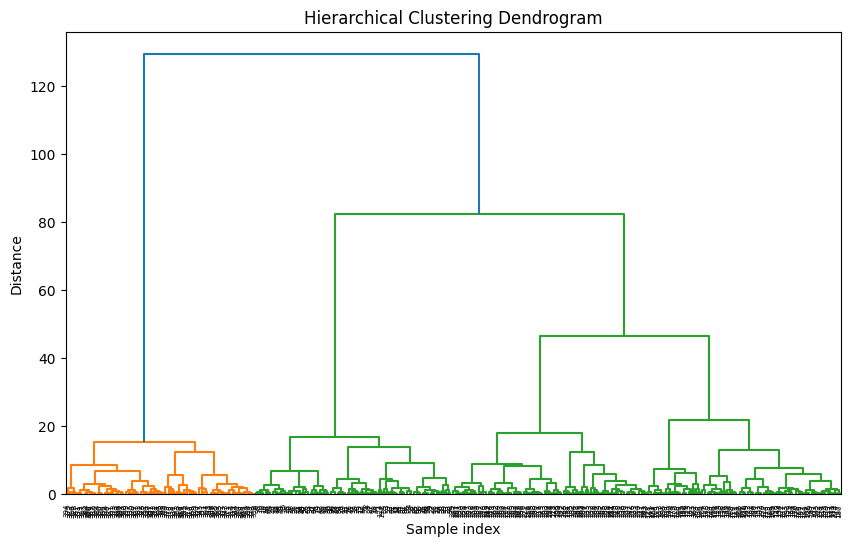

In [ ]:
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()

max_clusters = 4
labels = fcluster(Z, t=max_clusters, criterion='maxclust')
df['hier_cluster'] = labels

**c.** Can you decide the most suitable number of clusters from the previous dendrogram?

## 3. Real dataset

Now apply both algorithms on Kaggle [`California Housing Prices`](https://www.kaggle.com/datasets/camnugent/california-housing-prices). 

- Preprocess the data: missing values, encoding the categorical data, standardization...

- Detect the optimal number of clusters for this dataset.

- Perform PCA and visualize the obtained result. 

- Interpret each cluster.

In [21]:
import pandas as pd

house = pd.read_csv('housing.csv')
print(house.shape)
house.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [22]:
house.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [23]:
# missing data is only 1% of all data
house.dropna(inplace=True)

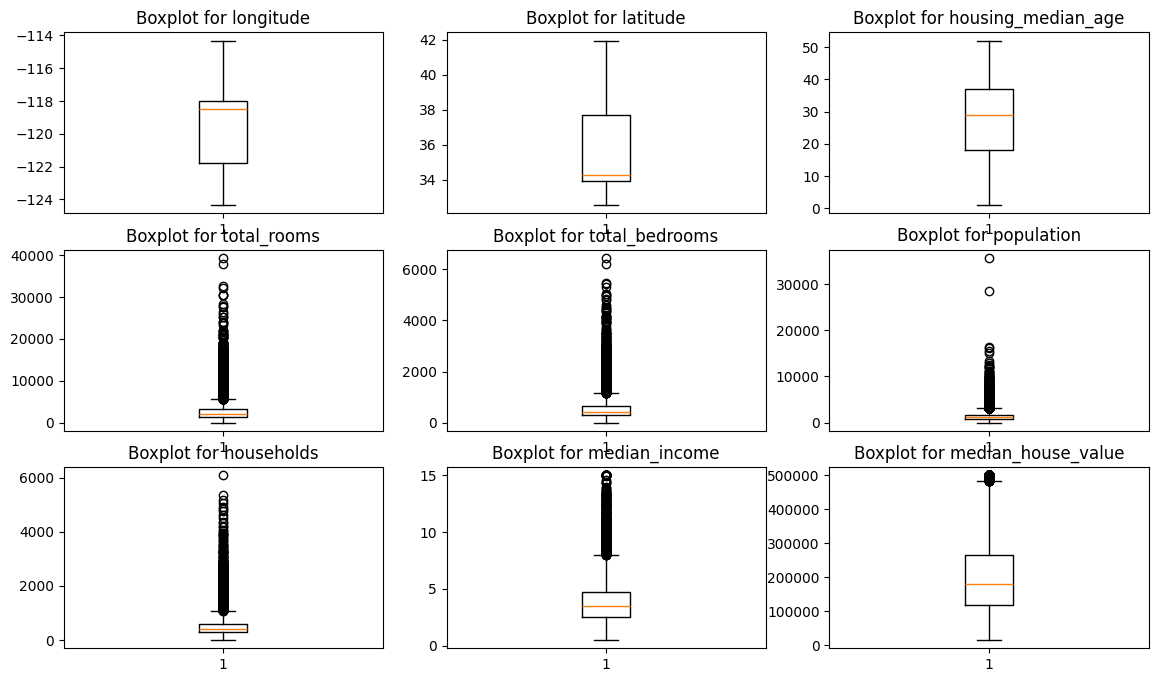

In [24]:
import matplotlib.pyplot as plt
num_col = house.select_dtypes(include='number').columns
fig, axes = plt.subplots(3, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_col):
    axes[i].boxplot(x=house[col])
    axes[i].set_title(f'Boxplot for {col}')
    

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
house['ocean_proximity'] = le.fit_transform(house['ocean_proximity'])

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(house.drop(columns=['ocean_proximity']))

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale only numerical columns
num_cols = house.select_dtypes(include=['number']).columns
cat_col = 'ocean_proximity'

scaler = StandardScaler()
X_scaled = scaler.fit_transform(house[num_cols])

df = pd.DataFrame(X_scaled, columns=num_cols)
df[cat_col] = house[cat_col].values


# Further Readings

- [Kmeansclustering](https://en.wikipedia.org/wiki/K-means_clustering)
- [Video: Kmean algorithm via vector quantization](https://www.youtube.com/watch?v=VcgIVW9M6D8&list=PLjTHlzp3MwkHq_WKcUtxXoeOHrPWFJIKF&index=2&ab_channel=SmallThings)
- [Hirachical clustering](https://en.wikipedia.org/wiki/Hierarchical_clustering)
- [KMeans, Sklearn](https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html)
- [Hirachical Clustering: AgglomerativeClustering, Sklearn](https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.AgglomerativeClustering.html#sklearn.cluster.AgglomerativeClustering)